# 09_聚类算法-GMM

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/lenna.jpg`。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 网络图片改为本地 lenna.jpg，用于像素聚类演示。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天要分享的内容是：GMM。

这个大家在未来的一个时候，肯定会用上，本文也会从你最实用的角度进行一个完整的分享。

首先呢，咱们先来看什么是聚类算法？

聚类算法是用来给数据分类的一种方法，但和分类不一样的是：

- 分类需要事先知道每个数据的类别，比如"苹果"、"香蕉"；
- 聚类不需要你事先告诉它类别，它会根据数据的特征，自己划分出一些组。

简单理解：**聚类算法就像给一堆乱七八糟的物品分组，尽量让每组的东西看起来像一家子。**

#### GMM是什么？

GMM（Gaussian Mixture Model，高斯混合模型）是一种比较聪明的聚类算法。

它假设数据来自于几个“高斯分布”（像钟形曲线那样的分布），然后根据这些分布把数据分组。

**特点：**

1. 它不像K-means（另一个常见的聚类算法）那样死板。K-means会把每个点分到某个固定的组里，GMM允许一个点有一定概率属于多个组。
2. 它更适合处理那些“分布有点像钟形曲线”的数据。

#### 一个非常通俗案例

**用GMM分组日常饮料**

想象一下，你去了一家超市，看到一堆饮料。这些饮料的包装上有两个关键信息：

1. **甜度**（如每100毫升糖含量，单位：克）。
2. **气泡强度**（如碳酸含量，单位：毫升）。

你的任务是按照饮料的特点，把它们分成两类：

- 一类是“气泡饮料”（比如可乐、雪碧）。
- 一类是“果汁饮料”（比如橙汁、苹果汁）。

#### 数据（假设有以下饮料）

| 饮料编号 | 甜度 (克/100ml) | 气泡强度 (毫升) |
|-|-|-|
| 1 | 10 | 50 |
| 2 | 12 | 45 |
| 3 | 5 | 10 |
| 4 | 4 | 15 |
| 5 | 11 | 55 |
| 6 | 6 | 12 |

#### 如何用GMM分组？

1. **假设每组数据来源于一个高斯分布**

   - 高斯分布形状像个钟，描述了数据分布的规律。
   - 比如，“气泡饮料”大多数甜度在10克左右，气泡强度在50毫升附近。
   - “果汁饮料”大多数甜度在5克左右，气泡强度在15毫升附近。
2. **定义分组数目**：我们假设有2类饮料（气泡饮料和果汁饮料）。
3. **初始化参数**

   - 初始估计每类饮料的高斯分布位置和形状，比如甜度和气泡强度的均值，以及它们的变化范围（标准差）。
   - 初始参数可能是：
   
     - 气泡饮料：甜度均值 = 10，气泡强度均值 = 50。
     - 果汁饮料：甜度均值 = 5，气泡强度均值 = 15。
4. **迭代优化**  
GMM会根据以下步骤不断优化分组：

   - **E步（Expectation，期望步）**：计算每种饮料属于两类中的概率。例如，饮料1更可能属于“气泡饮料”，而饮料3更可能属于“果汁饮料”。
   - **M步（Maximization，最大化步）**：根据概率重新计算每类饮料的均值和标准差。
5. **停止条件**  
当参数基本不变时（比如均值和标准差变化很小），分组结束。

#### 简单计算

这里，咱们手动模拟一下，大家就会更加的清楚\~

我们只计算第一步的“概率分配”：

**饮料1的甜度 = 10，气泡强度 = 50**

- 假设“气泡饮料”的高斯分布均值为甜度10，气泡强度50，标准差较小，饮料1几乎100%属于这类。
- 假设“果汁饮料”的高斯分布均值为甜度5，气泡强度15，饮料1属于这类的概率接近0。

**饮料3的甜度 = 5，气泡强度 = 10**

- 对“果汁饮料”，均值正好是甜度5，气泡强度15，饮料3的概率接近1。
- 对“气泡饮料”，均值是甜度10，气泡强度50，饮料3的概率接近0。

通过这样的步骤，GMM可以不断优化分组，直到稳定。

#### 总结3点

1. GMM假设数据来自多个高斯分布。
2. 通过计算每个点属于不同组的概率进行分组。
3. 它比K-means更灵活，适合有重叠区域的数据。

## 核心原理

高斯混合模型（GMM）通过多个高斯分布的线性组合来拟合数据的概率分布。

### 1. 高斯分布公式

单维高斯分布的概率密度函数（PDF）为：


$$
P(x|\mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
$$


其中：

- $\mu$：均值，决定分布的中心。
- $\sigma^2$：方差，决定分布的宽度。

对于多维数据（如 $x \in \mathbb{R}^d$），多维高斯分布的公式为：


$$
P(x|\mu, \Sigma) = \frac{1}{(2\pi)^{d/2} |\Sigma|^{1/2}} \exp\left(-\frac{1}{2}(x-\mu)^T \Sigma^{-1} (x-\mu)\right)
$$


其中：

- $\Sigma$：协方差矩阵，描述变量之间的线性关系。

### 2. 混合模型的定义

假设数据来自 $K$个高斯分布的混合，则数据点 $x$的概率为：


$$
P(x|\Theta) = \sum_{k=1}^K \pi_k P(x|\mu_k, \Sigma_k)
$$


其中：

- $\pi_k$：第 $k$个高斯分布的权重，满足 $\sum_{k=1}^K \pi_k = 1$和 $\pi_k \geq 0$。
- $\Theta = \{ \pi_k, \mu_k, \Sigma_k \}_{k=1}^K$是所有模型参数。

### 3. 最大似然估计（MLE）

我们希望通过最大化数据的似然函数来估计参数 $\Theta$：


$$
\mathcal{L}(\Theta) = \prod_{i=1}^N P(x_i|\Theta) = \prod_{i=1}^N \sum_{k=1}^K \pi_k P(x_i|\mu_k, \Sigma_k)
$$


为了方便计算，取对数得到对数似然：


$$
\log \mathcal{L}(\Theta) = \sum_{i=1}^N \log \left( \sum_{k=1}^K \pi_k P(x_i|\mu_k, \Sigma_k) \right)
$$


直接最大化对数似然比较困难，因此我们引入 EM 算法。

### 4. EM算法推导

#### a. 引入隐变量

假设我们不知道每个数据点 $x_i$属于哪个高斯分布，于是引入隐变量 $z_i$，表示 $x_i$属于第 $k$个分布的指示变量：

$z_i \in \{1, 2, ..., K\}$。

$P(z_i = k) = \pi_k$。

于是联合概率可以写成：


$$
P(x_i, z_i=k|\Theta) = \pi_k P(x_i|\mu_k, \Sigma_k)
$$


观测数据的边际概率为：


$$
P(x_i|\Theta) = \sum_{k=1}^K P(x_i, z_i=k|\Theta)
$$


#### b. EM算法分为两步

**E步（期望步）：计算隐变量的后验概率**

利用当前参数 $\Theta$，计算数据点 $x_i$属于第 $k$个分布的后验概率（即责任度）：


$$
\gamma_{ik} = P(z_i = k | x_i, \Theta) = \frac{\pi_k P(x_i|\mu_k, \Sigma_k)}{\sum_{j=1}^K \pi_j P(x_i|\mu_j, \Sigma_j)}
$$


其中：

- $\gamma_{ik}$：数据点 $x_i$属于第 $k$类的概率。

**M步（最大化步）：更新模型参数**

根据 E 步计算的 $\gamma_{ik}$，重新估计参数 $\Theta = \{\pi_k, \mu_k, \Sigma_k\}$。

1. 更新权重 $\pi_k$：  
$\pi_k = \frac{N_k}{N}, \quad N_k = \sum_{i=1}^N \gamma_{ik}$  
其中 $N_k$是属于第 $k$类的“有效样本数”。
2. 更新均值 $\mu_k$：  
$\mu_k = \frac{\sum_{i=1}^N \gamma_{ik} x_i}{N_k}$
3. 更新协方差矩阵 $\Sigma_k$：  
$\Sigma_k = \frac{\sum_{i=1}^N \gamma_{ik} (x_i - \mu_k)(x_i - \mu_k)^T}{N_k}$

### 5. 算法迭代过程

1. **初始化**：随机初始化均值 $\mu_k$、协方差 $\Sigma_k$和权重 $\pi_k$。
2. **E步**：根据当前参数计算每个点的责任度 $\gamma_{ik}$。
3. **M步**：利用责任度 $\gamma_{ik}$更新 $\pi_k, \mu_k, \Sigma_k$。
4. **收敛**：重复 E 步和 M 步，直到对数似然函数 $\log \mathcal{L}(\Theta)$收敛。

### 6. 总结一下核心公式

1. 责任度：  
$\gamma_{ik} = \frac{\pi_k P(x_i|\mu_k, \Sigma_k)}{\sum_{j=1}^K \pi_j P(x_i|\mu_j, \Sigma_j)}$
2. 权重更新：  
$\pi_k = \frac{\sum_{i=1}^N \gamma_{ik}}{N}$
3. 均值更新：  
$\mu_k = \frac{\sum_{i=1}^N \gamma_{ik} x_i}{\sum_{i=1}^N \gamma_{ik}}$
4. 协方差更新：  
$\Sigma_k = \frac{\sum_{i=1}^N \gamma_{ik} (x_i - \mu_k)(x_i - \mu_k)^T}{\sum_{i=1}^N \gamma_{ik}}$

### 7. GMM优势与局限

**优势**：

- 能处理复杂的分布（非球形、非均匀）。
- 输出是概率分布，可以处理软分类问题。

**局限**：

- 对参数初始化较为敏感。
- 计算复杂度较高，可能陷入局部最优。

通过以上公式和推理，咱们可以清楚理解 GMM 的理论基础\~

## 优缺点和适用场景

**优点**：

1. **适用于复杂数据分布**：GMM假设数据来自多个高斯分布的混合，因此可以处理复杂分布的数据，而不像K-Means要求数据具有球形分布。
2. **软分类**：GMM输出每个数据点属于某个簇的概率，而非硬性地将数据点划分到某个类中。这种柔性更适合处理边界模糊的分类问题。
3. **参数估计灵活**：可以估计每个簇的均值、协方差矩阵、权重等参数，适合不同形状和规模的簇。
4. **适合高维数据**：通过协方差矩阵，GMM能够自然地捕获数据在不同维度上的相关性。
5. **概率模型**：GMM是一种生成式模型，可以用于密度估计、异常检测等任务，而不仅仅是聚类。

**缺点**：

1. **对初始化敏感**：参数的初始值会极大影响结果，可能陷入局部最优。
2. **计算复杂度高**：每次迭代涉及全数据的概率计算和矩阵运算，对大规模数据较慢。
3. **假设高斯分布**：数据需要接近高斯分布。如果数据远离高斯分布，模型效果会降低。
4. **需要预先指定簇数** $K$：簇数是一个超参数，选择错误可能导致模型效果较差。
5. **可能过拟合**：如果数据维度较高或者簇数过多，GMM容易过拟合，导致泛化能力下降。

### 适用场景

1. **数据分布复杂但具有高斯特性**：如果数据的分布复杂，但每个子集看起来像高斯分布，可以使用GMM来建模。
2. **需要软分类**：比如区分客户购买倾向强弱，而不是硬性划分为“购买”或“不购买”。
3. **高维相关性分析**：数据的不同特征之间存在相关性时，协方差矩阵可以捕获这种关系。
4. **聚类、密度估计和异常检测**：GMM不仅可以用于聚类，还能估计数据的密度分布并检测异常点。

## 完整案例

下面，是一个基于 **图像分割** 案例的代码示例，使用 GMM 对图像像素进行聚类，将图像分成多个部分，并生成可视化图形。最终会展示：

1. 原始图像。
2. 分割后的图像（每个像素属于不同簇的标记）。
3. 使用簇的概率分布生成的软分类图像。

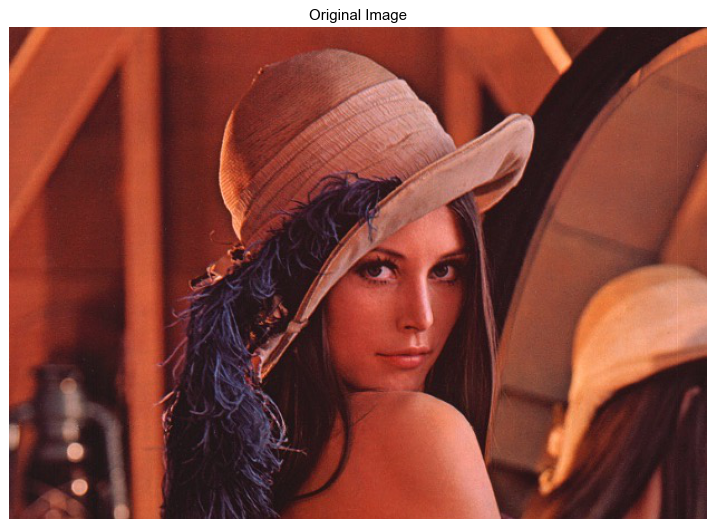

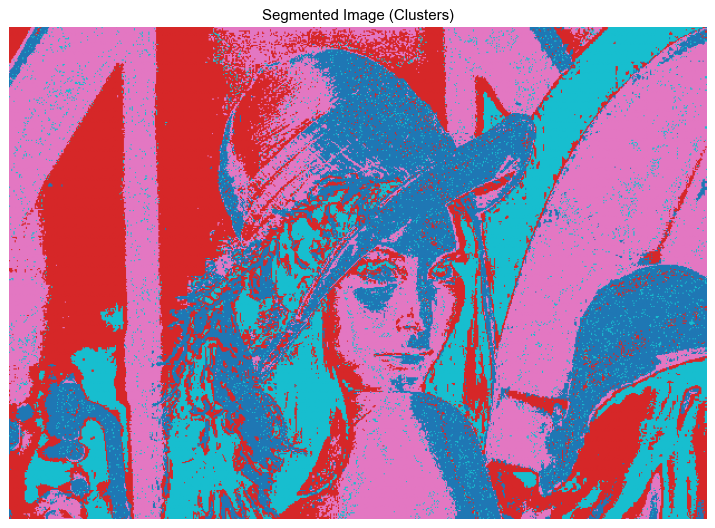

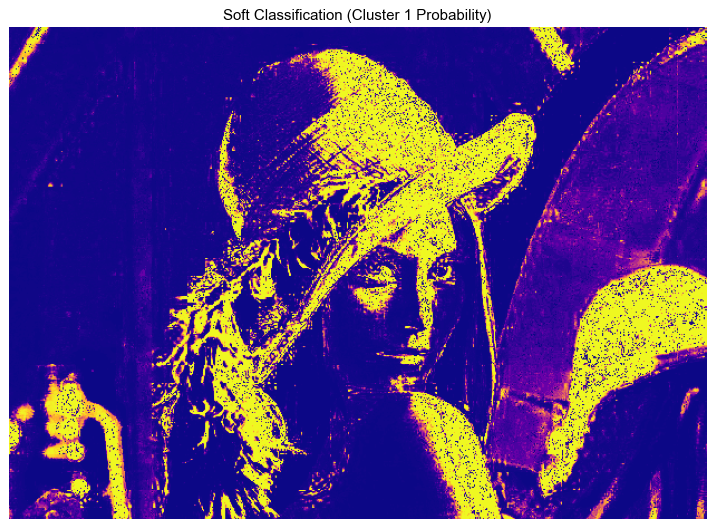

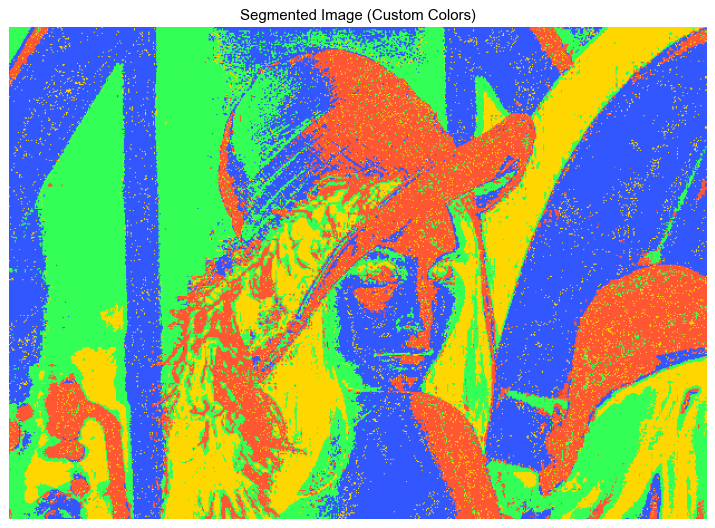

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from skimage import io
from matplotlib.colors import ListedColormap

import ssl

# 忽略 SSL 验证（如需要，可以打开）

# 加载图片（可以更换图片 URL）
image_path = DATA_DIR / 'lenna.jpg'
image = io.imread(image_path)

# 显示原始图片
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

# 将图片数据展平成二维 (宽×高, RGB)
image_data = image.reshape(-1, 3)

# 使用 GMM 进行聚类（假设分成 4 类）
n_clusters = 4
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
gmm.fit(image_data)

# 获取每个像素的簇标签
labels = gmm.predict(image_data)

# 重构分割图像
segmented_image = labels.reshape(image.shape[:2])

# 显示分割图像
plt.figure(figsize=(10, 10))
plt.imshow(segmented_image, cmap='tab10')
plt.title("Segmented Image (Clusters)")
plt.axis("off")
plt.show()

# 获取每个像素属于每个簇的概率
probabilities = gmm.predict_proba(image_data)

# 根据每个簇的概率生成软分类图像（示例：显示第一个簇的概率）
soft_image = probabilities[:, 0].reshape(image.shape[:2])

# 显示软分类图像
plt.figure(figsize=(10, 10))
plt.imshow(soft_image, cmap='plasma')  # 使用炫酷的 plasma 色图
plt.title("Soft Classification (Cluster 1 Probability)")
plt.axis("off")
plt.show()

# 为分割图像设置更复杂的色彩映射（自定义调色板）
custom_cmap = ListedColormap(["#FF5733", "#33FF57", "#3357FF", "#FFD700"])
plt.figure(figsize=(10, 10))
plt.imshow(segmented_image, cmap=custom_cmap)
plt.title("Segmented Image (Custom Colors)")
plt.axis("off")
plt.show()

1. **数据准备**：使用 `skimage.io` 加载在线图像。将图像数据展平为二维数组（每个像素为一个样本，RGB值为特征）。
2. **聚类分析**：使用 `sklearn.mixture.GaussianMixture` 进行聚类。`predict` 方法得到每个像素的簇标签，`predict_proba` 得到每个像素属于每个簇的概率。

- **原始图像**：显示原始图像。

![原文参考图，当前结果见代码输出](attachments/img_018.png)

- **分割图像**：显示每个像素的簇标签。

![原文参考图，当前结果见代码输出](attachments/img_019.png)

- **软分类图像**：显示某个簇的概率分布。

![原文参考图，当前结果见代码输出](attachments/img_020.png)

- **自定义色彩映射**：为分割图像添加的颜色。

![原文参考图，当前结果见代码输出](attachments/img_021.png)

这里有几点，大家注意下，可以更加好玩一些：

- 替换 `image_url` 为其他在线图像链接，效果更明显。
- 调整 `n_clusters` 改变分簇数目。
- 可以尝试其他炫酷的色彩映射，例如 `inferno`、`viridis`、`magma` 等。

运行后将获得复杂且炫酷的图像分析结果，结合 GMM 聚类算法展示了强大的图像分割功能。